In [7]:
import pandas as pd
import matplotlib.pyplot as plt

import torchmetrics.functional as Fmetrics
from torch import tensor

In [2]:
%load_ext tensorboard

In [8]:
def plot_predict(data: pd.DataFrame):
    """
    Plot prediction points gathered in prediction.csv and compute the global r².

    Parameters
    ----------
    data: pd.DataFrame
    Dataframe containing the prediction points.

    """

    # Compute R² score
    r2 = Fmetrics.regression.r2_score(tensor(data['predictions']), tensor(data['targets']), multioutput='uniform_average')

    # Plot predictions vs targets
    plt.figure(figsize=(10, 6))
    plt.scatter(data['targets'], data['predictions'], alpha=0.5)
    plt.plot([data['targets'].min(), data['targets'].max()], [data['targets'].min(), data['targets'].max()], 'r--')
    plt.xlabel('Targets')
    plt.ylabel('Predictions')
    plt.title(f'Predictions vs Targets (R² score: {r2:.2f})')
    plt.axis('equal')
    plt.show()

# Inference after global training (whole dataset)

In [4]:
%tensorboard --logdir=outputs/Africa_inf/tensorboard_logs  --host localhost

Launching TensorBoard...
Please visit http://localhost:6006 in a web browser.


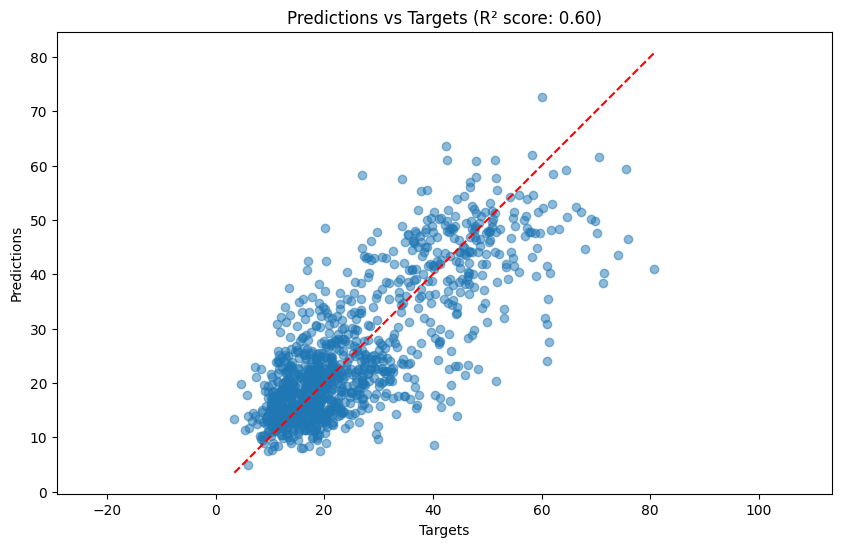

In [9]:
data = pd.read_csv(
    'outputs/Africa_inf/predictions.csv')
plot_predict(data)

# Inference after global training (no Madagascar)

In [7]:
%tensorboard --logdir=outputs/cnn_on_ms_poverty/kfolds_global_ms/tensorboard_logs/

Reusing TensorBoard on port 6007 (pid 8856), started 0:00:04 ago. (Use '!kill 8856' to kill it.)

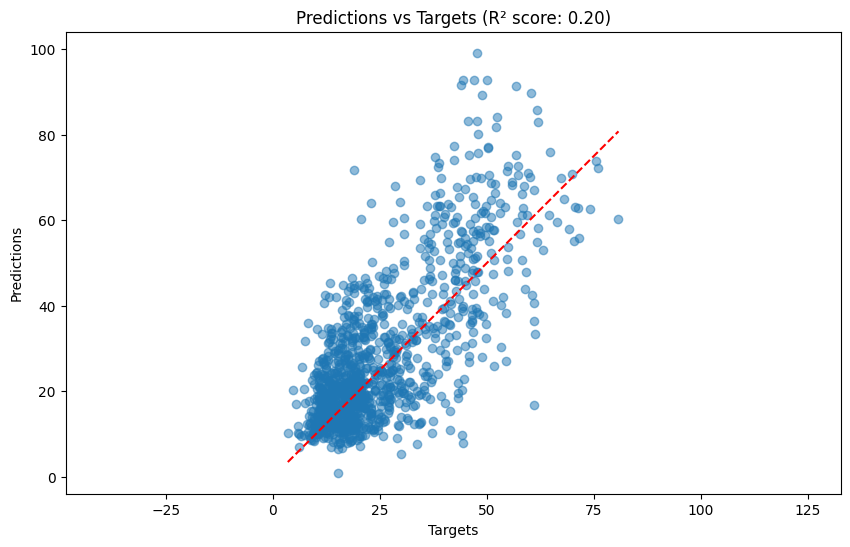

In [11]:
data = pd.read_csv('outputs/NoMada_inf/predictions.csv')
plot_predict(data)

# Fine-tuning on Madagascar after global training (whole dataset)

In [9]:
%tensorboard --logdir=outputs/cnn_on_ms_poverty/kfolds_global_rgb/tensoboard_logs

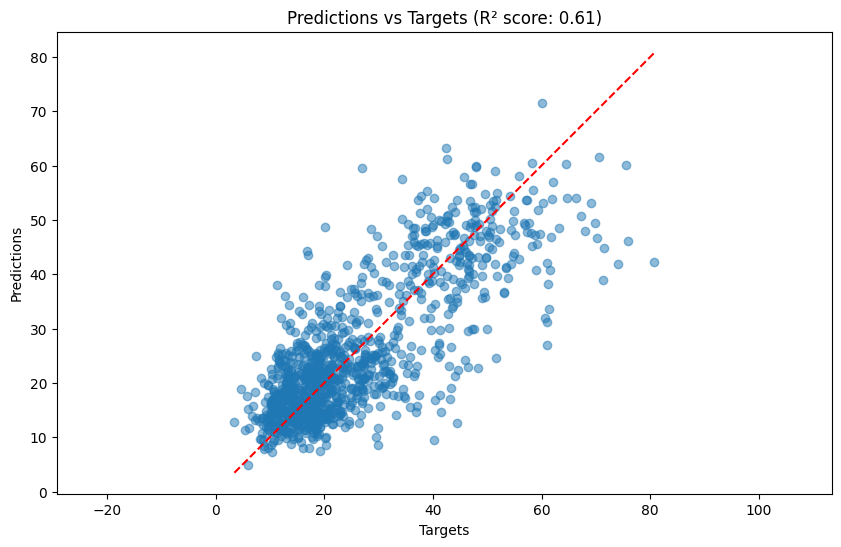

In [12]:
data = pd.read_csv('outputs/Africa_FT_inf/predictions.csv')
plot_predict(data)

# Fine-tuning on Madagascar after global training (no Madagascar)

In [11]:
%tensorboard --logdir=outputs/cnn_on_ms_poverty/kfolds_global_rgb_imagenet/tensorboard_logs

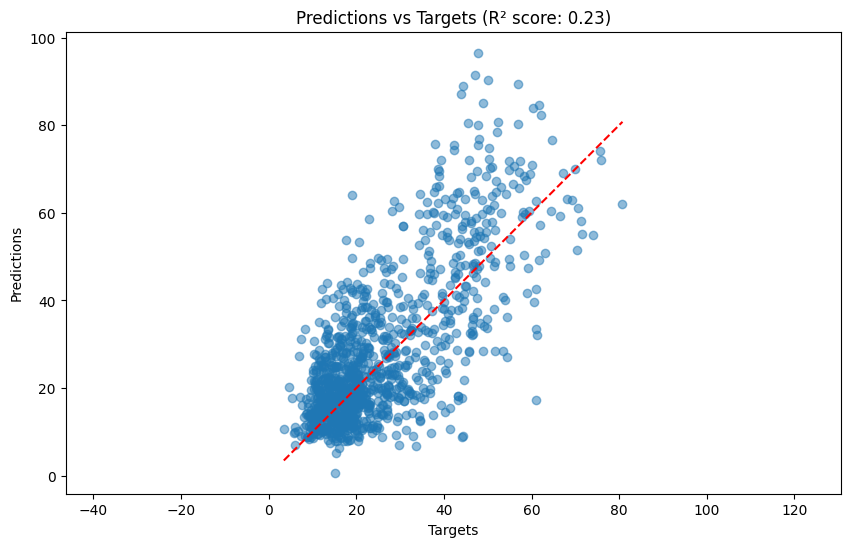

In [13]:
data = pd.read_csv('outputs/NoMada_FT_inf/predictions.csv')
plot_predict(data)